# Data Initialization


In [232]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch


raw_df = pd.read_csv('weekly_player_stats_offense.csv')
rng = np.random.RandomState(seed=67)
torch.manual_seed(67)
#device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(device)

run_long = True # flag to prevent running of expensive code when running all blocks

cuda:0


In [233]:
# Holden: initialize labels of features to be used or excluded by model
categorical_features = set([])
real_val_features = set([])
metadata = ['player_id', 'season', 'week', 'player_name']
target_col = 'next_week_fp'

In [234]:
#target engineering for RNN
window = 3 # Number of weeks used to formulate rolling averages
raw_df = raw_df.sort_values(['player_id', 'season', 'week']) 
raw_df[target_col] = raw_df.groupby(['player_id', 'season'])['fantasy_points_ppr'].shift(-1)

# rolling
raw_df['avg_fp_ppr'] = (raw_df.groupby(['player_id', 'season'])['fantasy_points_ppr'] 
                        .transform(lambda x : x.shift(-1).rolling(window=window, min_periods=1).mean()))

In [235]:
# initialize feature lists sorting by datatype
for col in raw_df.columns :
    if pd.api.types.is_numeric_dtype(raw_df[col]) :
        if col == target_col :
            continue
        else :
            real_val_features.add(col)
    else :
        categorical_features.add(col)
# remove metadata from feature lists
categorical_features.difference_update(metadata)
real_val_features.difference_update(metadata)

In [236]:
# generate a dataframe to measure feature usability 
rv_stats = []
for col in raw_df[list(real_val_features)].columns: 
    s = raw_df[col]
    t = raw_df[target_col]

    mask = s.notna() & t.notna()
    s = s[mask]
    t = t[mask]

    non_nan = mask.mean()
    non_zero = (s != 0).mean()
    std = s.std()

    if std > 0 and t.std() > 0 :
        corr = s.corr(t)
    else :
        corr = np.nan

    rv_stats.append({
        "feature": col,
        "frac_non_nan": non_nan,
        "frac_non_zero": non_zero,
        "std": std,
        "corr_with_target": corr,
        "abs_corr": abs(corr) if pd.notna(corr) else np.nan,
    })

feature_stats = pd.DataFrame(rv_stats) 

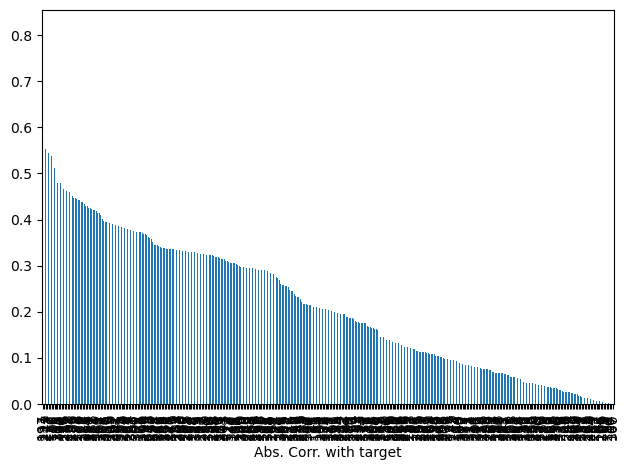

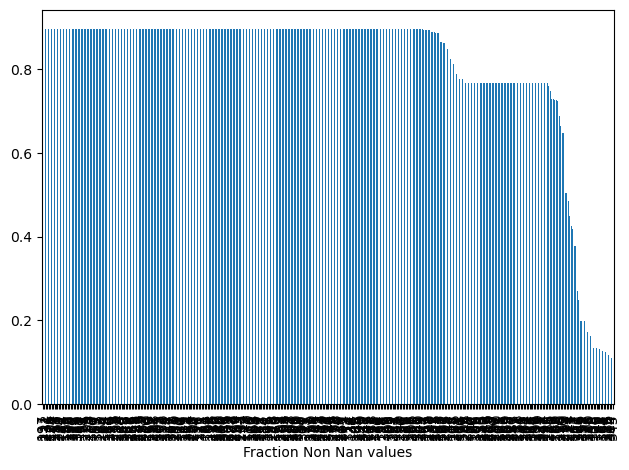

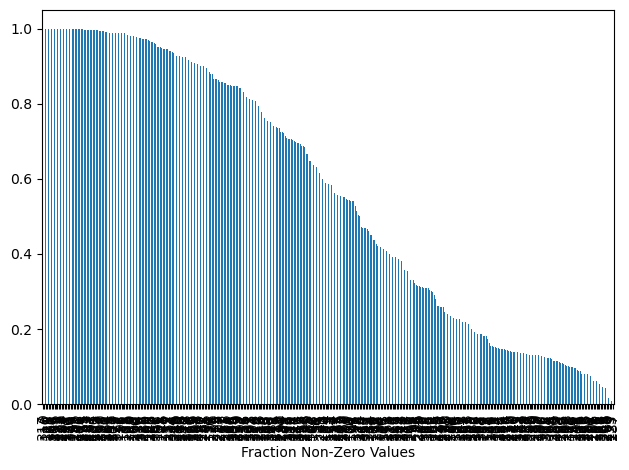

,frac_non_nan,frac_non_zero,std,corr_with_target,abs_corr
count,384.000000,384.000000,384.000000,384.000000,384.000000
mean,0.811612,0.565253,107.909895,0.204776,0.217018
std,0.192239,0.346246,501.369390,0.164311,0.147721
min,0.083372,0.002642,0.027405,-0.318256,0.000119
25%,0.767317,0.200930,0.691983,0.075547,0.083435
50%,0.897372,0.587332,3.971183,0.202705,0.204383
75%,0.897372,0.924181,22.035421,0.331219,0.331219
max,0.897372,1.000000,6129.035416,0.813747,0.813747


In [237]:

feature_stats = feature_stats.sort_values('abs_corr', ascending=False)
feature_stats['abs_corr'].plot(kind='bar')
plt.xlabel("Abs. Corr. with target")
plt.tight_layout()
plt.show()

feature_stats = feature_stats.sort_values('frac_non_nan', ascending=False)
feature_stats['frac_non_nan'].plot(kind='bar')
plt.xlabel('Fraction Non Nan values')
plt.tight_layout()
plt.show()

feature_stats = feature_stats.sort_values('frac_non_zero', ascending=False)
feature_stats['frac_non_zero'].plot(kind='bar')
plt.xlabel("Fraction Non-Zero Values")
plt.tight_layout()
plt.show()
feature_stats.describe()


In [238]:
# cut off any features that are in the bottom 25% of 
# any of the relevance/usability metrics
abs_corr_thresh = feature_stats['abs_corr'].quantile(.25)
non_nan_thresh = feature_stats['frac_non_nan'].quantile(.25)
non_zero_thresh= feature_stats['frac_non_zero'].quantile(.25)

keep_mask = (
    (feature_stats['abs_corr'] >= abs_corr_thresh) &
    (feature_stats['frac_non_nan'] >= non_nan_thresh) &
    (feature_stats['frac_non_zero'] >= non_zero_thresh)
)
keep = feature_stats[keep_mask]['feature'].tolist()
real_val_features.intersection_update(keep)
print(f'Pruned real value features down to {len(real_val_features)} features')

Pruned real value features down to 197 features


In [239]:
# test train split 
# pre process
# drop NaN target rows
# build sequences


In [240]:
from sklearn.preprocessing import OneHotEncoder,  StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
#sort real value features by estimated distribution type
categorical_features.difference_update(['college', 'team']) # after shap analysis college and team features  had minimal importance and added significant dimensionality
real_val_features = list(real_val_features)
categorical_features = list(categorical_features)


rv_split_std = []
rv_split_skewed = []
rv_split_few = []
for feature in real_val_features:
    column = raw_df[feature]
    unique_vals = column.nunique(dropna=True)

    if unique_vals <= 2 :
        rv_split_few.append(feature)
    else :
        skew = column.skew(skipna=True)
        if abs(skew) > 1 :
            rv_split_skewed.append(feature)
        else :
            rv_split_std.append(feature)

std_pipline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

skewed_pipline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

no_scale_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')) 
])

categorical_pipeline = Pipeline(steps=[
    ('OHE', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(transformers=[
    ('norm_rv', std_pipline, rv_split_std),
    ('skewed_rv', skewed_pipline, rv_split_skewed),
    ('few_rv', no_scale_pipeline, rv_split_few),
    ('categorical', categorical_pipeline, list(categorical_features))
    ])


In [241]:
# season split for training, validation, and testing 
# 70% of data is before 2021 week 10, so all of 2021 will be used for training
# 2022 and 23 will be validation 
# 24 will be test set  
#   - add 2025 using espn api if possible 
train_seasons = np.arange(2012, 2021,1)
val_seasons = [2022, 2023]
test_seasons = [2024]

train_df = raw_df[raw_df['season'].isin(train_seasons)]
val_df = raw_df[raw_df['season'].isin(val_seasons)]
test_df = raw_df[raw_df['season'].isin(test_seasons)]


X_train = preprocess.fit_transform(train_df)
X_val = preprocess.transform(val_df)
X_test= preprocess.transform(test_df)

y_train = train_df[target_col].to_numpy()
y_val = val_df[target_col].to_numpy()
y_test = test_df[target_col].to_numpy()

#remove samples with nan targets ie no next week to predict for the season
train_mask = ~np.isnan(y_train)
val_mask = ~np.isnan(y_val)
test_mask = ~np.isnan(y_test)

train_df = train_df[train_mask]
val_df = val_df[val_mask]
test_df = test_df[test_mask]


X_train = X_train[train_mask]
y_train = y_train[train_mask]

X_val = X_val[val_mask]
y_val = y_val[val_mask]

X_test = X_test[test_mask]
y_test = y_test[test_mask]



In [242]:

def make_sequences(df, X, y, grouping=['player_id', 'season'], time=['week']) :
    '''
    df = split specific dataframe
    X = processed array derived from df
    y = array of targets for X
    grouping + time = lists of columns used for time indexing 
    '''


    df = df.copy()
    df['idx'] = np.arange(len(df))
    df = df.sort_values(grouping + time)

    seqs = []
    targets = []
    lengths = []

    # split dataframe by player-season
    for _, g in df.groupby(grouping, sort=False) : 
        idxs = g['idx'].to_numpy()
        gX = X[idxs] # array of features for current player-season 
        gy = y[idxs] # targets for each week of player-season

        T = len(gX) # number of weeks in current 
        if T == 0 :
            continue
        
        # for each week j in player-season :
        #   build sequence of features leading up to week j
        #   target is target[week j] ie 
        #   features from weeks 1-7 -> target is week 8's ppr-points
        for j in range(T) : 
            start = 0 
            end = j + 1

            X_seq = gX[start:end]
            y_val = gy[j]

            seqs.append(X_seq) # input sequence
            targets.append(y_val) # target for week j of sequence
            lengths.append(X_seq.shape[0])


    # pad sequences to all be same size for NN input 
    max_len = max(lengths)
    num_features = seqs[0].shape[1]
    # returned array initialized to 0s in shape of total sequences , longest sequence, total features
    X_padded = np.zeros((len(seqs), max_len, num_features), dtype=np.float32)

    # add actual values to zeroed array 
    for i, (seq, L) in enumerate(zip(seqs, lengths)) :
        X_padded[i , :L , :] = seq


    y_seq = np.array(targets, dtype=np.float32)
    lengths = np.array(lengths, dtype=np.float32)

    #return array for NN input, the array's targets, and the non-zero lengths
    return X_padded, y_seq, lengths


In [243]:
X_train_seqs, y_train_seqs, train_lengths = make_sequences(train_df, X_train, y_train)

X_val_seqs, y_val_seqs, val_lengths = make_sequences(val_df, X_val, y_val)

X_test_seqs, y_test_seqs, test_lenghts = make_sequences(test_df, X_test, y_test)



In [244]:
import torch
from torch.utils.data import Dataset

class FantasyDataset(Dataset) : 
    def __init__(self, X, y, lengths) :
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1,1)
        self.lengths = torch.tensor(lengths, dtype=torch.int64)
    def __len__(self) :
        return len(self.X)
    
    def __getitem__(self, idx) : 
        return self.X[idx] , self.y[idx], self.lengths[idx]

In [245]:
from torch.utils.data import DataLoader
bs = 64

train_set = FantasyDataset(X_train_seqs, y_train_seqs, train_lengths)
val_set = FantasyDataset(X_val_seqs, y_val_seqs, val_lengths)
test_set = FantasyDataset(X_test_seqs, y_test_seqs,test_lenghts)

train_loader = DataLoader(dataset=train_set, batch_size=bs, shuffle=False, num_workers=0)
val_loader = DataLoader(dataset=val_set, batch_size=bs, shuffle=False, num_workers=0)
test_loader = DataLoader(dataset=test_set, batch_size=bs, shuffle=False, num_workers=0)

# Model Implementation and Analysis

In [246]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from torch import nn, optim
from torch.nn.utils.rnn import pack_padded_sequence

class MLP_Network(nn.Module) :
    def __init__(self, input_size, hidden_sizes, num_classes, dropout_prob=.2) :
        super(MLP_Network, self).__init__()

        self.input_size = input_size
        layers = []
        prev_dim = input_size

        for size in hidden_sizes :
            layers.append(nn.Linear(prev_dim, size))
            layers.append(nn.ReLU())
            if dropout_prob > 0: 
                layers.append(nn.Dropout(dropout_prob))
            prev_dim = size

        layers.append(nn.Linear(prev_dim, num_classes))
        
        self.net = nn.Sequential(*layers)
        self._init_weights()
        
    def _init_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')
                nn.init.constant_(layer.bias, 0)

    # MLP expects single size data, so use last time step of sequence as input
    def forward(self, x, lengths) :
        batch_size, max_len, feats = x.shape
        idx = (lengths - 1).clamp(min=0 , max=max_len-1)

        batch_idx = torch.arange(batch_size, device=x.device)
        x_flat = x[batch_idx, idx, :]

        return self.net(x_flat)

In [247]:
# Skye Ramsey: Made the initial version of the model class
class RNNRegressor(nn.Module):
    """LSTM-based regressor for sequential data"""
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2, bidirectional=False):
        super().__init__()
        self.bidirectional = 2 if bidirectional else 1
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )
        self.fc = nn.Linear(hidden_size * self.bidirectional, 1)
        self._init_weights()

    def _init_weights(self):
        for name, param in self.lstm.named_parameters() :
            if 'weight' in name:
                nn.init.xavier_uniform_(param)
            elif 'bias' in name:
                nn.init.constant_(param, 0)
        nn.init.xavier_uniform_(self.fc.weight)
        nn.init.constant_(self.fc.bias, 0)

    def forward(self, x, lengths) :

        packed = pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_out, (h_n, c_n) = self.lstm(packed)
        
        if self.bidirectional == 2 :
            h_forward = h_n[-2]
            h_backward = h_n[-1]
            last_layer = torch.cat([h_forward, h_backward], dim=1)
        else :
            last_layer = h_n[-1]

        out = self.fc(last_layer)
        return out


In [ ]:

class GRURegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=.2, bidirectional=False):
        super().__init__()
        self.bidirectional = 2 if bidirectional else 1
        
        self.gru = nn.GRU(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers=num_layers, 
            batch_first=True, 
            dropout=dropout if num_layers > 1 else 0, 
            bidirectional=bidirectional
        )        
        self.fc = nn.Linear(hidden_size * self.bidirectional, 1)
        self._init_weights()

    def _init_weights(self):
        for name, param in self.gru.named_parameters():
            if 'weight' in name:
                nn.init.xavier_uniform_(param)
            elif 'bias' in name:
                nn.init.constant_(param, 0)
        nn.init.xavier_uniform_(self.fc.weight)
        nn.init.constant_(self.fc.bias, 0)

    def forward(self, x, lengths):
        packed = pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_out, h_n = self.gru(packed)

        if self.bidirectional == 2 :
            h_forward = h_n[-2]
            h_backward = h_n[-1]
            last_layer = torch.cat(h_forward, h_backward, dim=1)
        else :
            last_layer = h_n[-1]

        out = self.fc(last_layer)
        return out


In [ ]:

def train_torch_model(model, train_loader, val_loader, num_epochs=100, learning_rate=.001, device='cpu'):
    model = model.to(device)
    criterion = nn.HuberLoss(delta=1.0)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for x, y, lengths in train_loader :
            
            x = x.to(device)
            y = y.to(device)
            lengths = lengths.to(device)

            optimizer.zero_grad()

            outputs = model(x, lengths)

            loss = criterion(outputs, y)
            loss.backward()

            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, y, lengths in val_loader :
                x = x.to(device)
                y = y.to(device)
                lengths = lengths.to(device)

                outputs = model(x, lengths)

                loss = criterion(outputs, y)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        if epoch == 25 or epoch == 50 or epoch == 75 or epoch == 100 or epoch == num_epochs:
            print(f"Epoch: {epoch}'s train loss= {train_loss} and val loss= {val_loss}")

    return model, train_losses, val_losses

def evaluate_torch_model(model, loader, device='cpu'):
    model.eval()
    preds = []
    acts = []

    with torch.no_grad():
        for x, y, lengths in loader:
            x = x.to(device)
            lengths = lengths.to(device)
            
            outputs = model(x, lengths)
            preds.append(outputs.cpu())
            acts.append(y.cpu())

    preds = torch.cat(preds , dim=0)
    acts = torch.cat(acts, dim=0)

    preds = preds.view(-1).numpy() 
    acts = acts.view(-1).numpy()
    
    mse = mean_squared_error(acts, preds)
    mae = mean_absolute_error(acts, preds)
    r2 = r2_score(acts, preds)

    return mse, mae, r2, preds, acts

In [ ]:
input_size = train_set.X.shape[2] # num_features for input 
gru_model = GRURegressor(input_size=input_size)

if run_long :
    minion, gru_tl, gru_vl = train_torch_model(gru_model, train_loader, val_loader,device=device)

In [ ]:

gru_mse, gru_mae, gru_r2, preds, acts = evaluate_torch_model(minion, test_loader,device=device)


In [ ]:
#MLP model significantly lower performance than GRU or LSTM
mlp_model = MLP_Network(input_size, [128, 64], num_classes=1)

if run_long :
    trained_mlp, mlp_tl, mlp_vl = train_torch_model(mlp_model, train_loader, val_loader, device=device)

    mlp_mse, mlp_mae, mlp_r2, preds, acts = evaluate_torch_model(trained_mlp, test_loader,device=device)




In [ ]:
lstm_model = RNNRegressor(input_size)
if run_long :
    trained_lstm, lstm_tl, lstm_vl = train_torch_model(lstm_model, train_loader, val_loader,device=device)

    lstm_mse, lstm_mae, lstm_r2, preds, acts = evaluate_torch_model(trained_lstm, test_loader,device=device)



Epoch: 25's train loss= 1.4670862634700756 and val loss= 1.1885053568057247
Epoch: 50's train loss= 1.3323439130904497 and val loss= 1.1732703863636598
Epoch: 75's train loss= 1.2367560735248304 and val loss= 1.1282408880916508


LSTM Accuracy scores:
	R^2: 0.80626380443573
	MSE: 14.826263427734375
	 MAE:1.4989126920700073


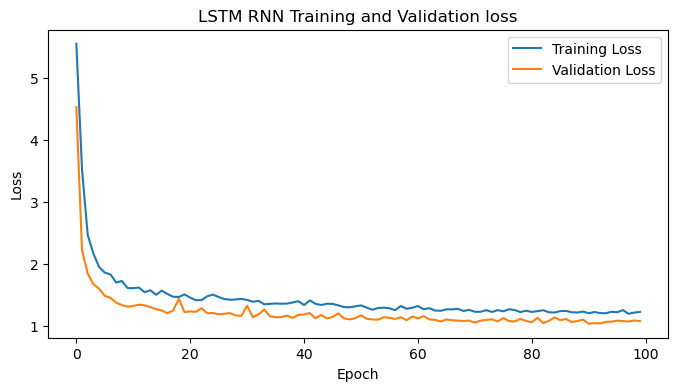

In [ ]:
print(f'Gru Accuracy scores:\n\tR^2: {gru_r2}\n\tMSE: {gru_mse}\n\t MAE:{gru_mae}')
plt.figure(figsize=(8, 4))
plt.plot(range(100), gru_tl, label='Training Loss',)
plt.plot(range(100), gru_vl, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Gru Training and Validation loss')
plt.show()

print(f'MLP Accuracy scores:\n\tR^2: {mlp_r2}\n\tMSE: {mlp_mse}\n\t MAE:{mlp_mae}')
plt.figure(figsize=(8, 4))
plt.plot(range(100), mlp_tl, label='Training Loss',)
plt.plot(range(100), mlp_vl, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('MLP Training and Validation loss')
plt.show()

print(f'LSTM Accuracy scores:\n\tR^2: {lstm_r2}\n\tMSE: {lstm_mse}\n\t MAE:{lstm_mae}')
plt.figure(figsize=(8, 4))
plt.plot(range(100), lstm_tl, label='Training Loss',)
plt.plot(range(100), lstm_vl, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('LSTM RNN Training and Validation loss')
plt.show()

### Feature Importance Evaluation

In [ ]:
# wrapper model class to use for shap evaluation 
from torch import nn
class RNNWrapper(nn.Module) :
    def __init__(self, base_model) :
        super().__init__()
        self.base = base_model

    def forward(self, x) :

        with torch.no_grad():
            mask =(x.abs().sum(dim=2) > 0)
            lengths = mask.sum(dim =1)
    
        lengths = lengths.to(x.device)
        return self.base(x,lengths)


In [ ]:
import shap

#shap require model to be on cpu
best_model_cpu = trained_lstm.to('cpu')
best_model_cpu.eval()

wrapped_model = RNNWrapper(best_model_cpu).to('cpu')
wrapped_model.eval()

X_val_seqs = X_val_seqs.astype(np.float32)

#shap background and explanation datasets
N_bg = min(200, X_val_seqs.shape[0])       
N_explain = min(300, X_val_seqs.shape[0])  
X_bg = torch.from_numpy(X_val_seqs[:N_bg])        
X_explain = torch.from_numpy(X_val_seqs[:N_explain])

explainer = shap.DeepExplainer(wrapped_model, X_bg)
shap_vals = explainer.shap_values(X_explain, check_additivity=False)   


In [265]:
if isinstance(shap_vals, list):
        shap_vals = shap_vals[2]  


global_importance = np.mean(np.abs(shap_vals), axis=(0, 1))

feature_names = preprocess.get_feature_names_out()
ranking = sorted(
    zip(feature_names, global_importance),
    key=lambda x: x[1],
    reverse=True
)

# code used to print shap results
from io import StringIO
import sys

buffer = StringIO()
old_stdout = sys.stdout
sys.stdout = buffer

for name, score in ranking :
    print(f"{name:25s} mean|SHAP| = {float(score):.4f}") 

sys.stdout = old_stdout

with open('shap_importance.txt', 'w') as f :
    f.write(buffer.getvalue())


(223,)
223
(223,)


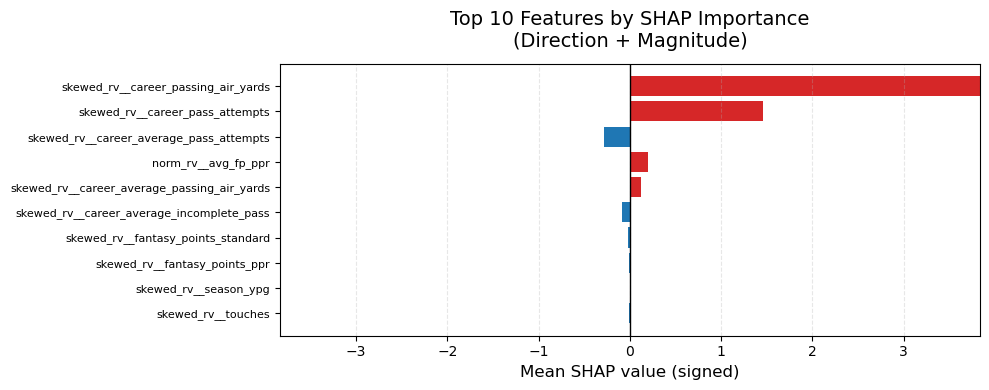

In [ ]:
mean_shap = np.mean(shap_vals, axis=(0,1))
mean_shap = mean_shap.reshape(-1)
importance = np.abs(mean_shap)

shap_df = pd.DataFrame({
    'feature' : feature_names ,
    'mean_shap' : mean_shap,
    'importance' : importance
})


# sort by importance and keep top K
shap_df = shap_df.sort_values("importance", ascending=False).head(10).copy()

shap_df = shap_df.iloc[::-1]

# color by sign
colors = np.where(shap_df["mean_shap"] > 0, "tab:red", "tab:blue")

plt.figure(figsize=(10, 4))  # scale height with K

plt.barh(shap_df["feature"], shap_df["mean_shap"], color=colors)
plt.axvline(0, color="black", linewidth=1)

plt.xlabel("Mean SHAP value (signed)", fontsize=12)
plt.title(f"Top {10} Features by SHAP Importance\n(Direction + Magnitude)",
          fontsize=14, pad=12)

plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tick_params(axis="y", labelsize=8)
plt.xlim(-max_abs, max_abs)
plt.tight_layout()
plt.show()

In [ ]:
# features from top 100 eligible for rolling average 
rolling_candidates = []
for feature, importance in ranking[:100]:
    if 'career' in feature or 'season' in feature or 'categorical' in feature or 'ppr' in feature or 'draft' in feature:
        continue
    rolling_candidates.append(feature)

print(len(rolling_candidates))
print(rolling_candidates)

9
['skewed_rv__fantasy_points_standard', 'skewed_rv__touches', 'skewed_rv__total_yards', 'skewed_rv__qb_dropback', 'skewed_rv__total_tds', 'skewed_rv__receptions', 'skewed_rv__pass_touchdown', 'skewed_rv__rush_attempts', 'skewed_rv__targets']
